In [4]:
import itertools
import re
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.io import loadmat
from scipy.stats import wilcoxon

REPO = Path.cwd()
EXPORT_DIR = REPO / "data" / "export"
WIN_DEFS = REPO / "data" / "windows" / "win_defs_Simon.mat"
NOTES_DIR = REPO / "data" / "lab-notes"
SUMMARY_CSV = REPO / "summary.csv"

# 000Q is the quality/control stimulus, "fail" collects discarded sweeps.
EXCLUDE_STIMIDS = {"000Q", "fail"}

# A condition is only analysed if it was recorded in every cell with at least this
# many blocks and trials. This drops aborted recordings such as PMSEZelle02's MBA.
MIN_BLOCKS_PER_CONDITION = 4
MIN_TRIALS_PER_BLOCK = 5

N_EVENTS = 8
ALPHA = 0.05

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 9,
})

COND_STYLE = {
    "MAB": {"color": "tab:blue", "marker": "o"},
    "MAC": {"color": "tab:orange", "marker": "s"},
    "MAD": {"color": "tab:green", "marker": "^"},
}

print(f"repo        : {REPO}")
# TODO: maybe convert xlsx to csv?!
print(f"exports     : {len(list(EXPORT_DIR.glob('*.xlsx')))} xlsx files")
print(f"window defs : {WIN_DEFS.name}")

repo        : /Users/simon/GitRepos/neurophysiology-project
exports     : 7 xlsx files
window defs : win_defs_Simon.mat


In [5]:
_mat = loadmat(WIN_DEFS)
win_names = [str(x[0]) for x in _mat["names"].ravel()]
win_bounds = _mat["winDefs"].astype(int)

windows = pd.DataFrame(win_bounds, index=win_names, columns=["start_ms", "end_ms"])
windows["dur_ms"] = windows["end_ms"] - windows["start_ms"]

# Discontinuity onset is the end of the baseline window that precedes it.
ONSETS = windows.loc[[f"B{i}" for i in range(1, N_EVENTS + 1)], "end_ms"].to_numpy()

for i in range(1, N_EVENTS + 1):
    b, t = windows.loc[f"B{i}"], windows.loc[f"T{i}"]
    onset = b["end_ms"]
    assert b["dur_ms"] == 50, f"B{i} is {b['dur_ms']} ms, paper uses a 50 ms baseline"
    assert t["dur_ms"] == 150, f"T{i} is {t['dur_ms']} ms, paper uses a 150 ms window"
    assert t["start_ms"] - onset == 10, f"T{i} starts {t['start_ms'] - onset} ms after onset, paper uses 10 ms"

print(windows.to_string())
print()
print(f"discontinuity onsets (ms): {ONSETS.tolist()}")
print(f"inter-event spacing (ms) : {np.diff(ONSETS).tolist()}")
print()
print("Windows match Kurtz et al. 2009: baseline = 50 ms ending at onset,")
print("modulation = 150 ms starting 10 ms after onset.")

       start_ms  end_ms  dur_ms
Rest        500    1000     500
Post1      8900    9400     500
B1         1770    1820      50
B2         2600    2650      50
B3         3430    3480      50
B4         4270    4320      50
B5         5100    5150      50
B6         5930    5980      50
B7         6770    6820      50
B8         7600    7650      50
T1         1830    1980     150
T2         2660    2810     150
T3         3490    3640     150
T4         4330    4480     150
T5         5160    5310     150
T6         5990    6140     150
T7         6830    6980     150
T8         7660    7810     150

discontinuity onsets (ms): [1820, 2650, 3480, 4320, 5150, 5980, 6820, 7650]
inter-event spacing (ms) : [830, 830, 840, 830, 830, 840, 830]

Windows match Kurtz et al. 2009: baseline = 50 ms ending at onset,
modulation = 150 ms starting 10 ms after onset.


In [6]:
_XL_NS = "{http://schemas.openxmlformats.org/spreadsheetml/2006/main}"


def _col_to_index(letters):
    idx = 0
    for ch in letters:
        idx = idx * 26 + ord(ch) - 64
    return idx


def read_xlsx(path):
    """Read the first worksheet of an xlsx file into a DataFrame (stdlib only)."""
    with zipfile.ZipFile(path) as zf:
        shared = []
        if "xl/sharedStrings.xml" in zf.namelist():
            for si in ET.fromstring(zf.read("xl/sharedStrings.xml")):
                shared.append("".join(t.text or "" for t in si.iter(f"{_XL_NS}t")))
        sheet = ET.fromstring(zf.read("xl/worksheets/sheet1.xml"))

    rows = {}
    for cell in sheet.iter(f"{_XL_NS}c"):
        match = re.match(r"([A-Z]+)(\d+)", cell.get("r"))
        value_node = cell.find(f"{_XL_NS}v")
        if value_node is None or value_node.text is None:
            value = None
        elif cell.get("t") == "s":
            value = shared[int(value_node.text)]
        else:
            value = float(value_node.text)
        rows.setdefault(int(match.group(2)), {})[_col_to_index(match.group(1))] = value

    header = {col: name for col, name in rows[1].items()}
    records = [
        {name: rows[r].get(col) for col, name in header.items()}
        for r in sorted(rows)
        if r > 1
    ]
    return pd.DataFrame.from_records(records)


def parse_stim_id(stim_id):
    """Split e.g. 'MAB3' into ('MAB', 3). Returns (stim_id, None) if it does not match."""
    match = re.fullmatch(r"([A-Z]{3})(\d)", str(stim_id))
    return (match.group(1), int(match.group(2))) if match else (str(stim_id), None)


raw_frames = []
for path in sorted(EXPORT_DIR.glob("PMSEZelle*_export_*.xlsx")):
    frame = read_xlsx(path)
    frame.insert(0, "cell", re.search(r"(PMSEZelle\d+)", path.name).group(1))
    raw_frames.append(frame)

raw = pd.concat(raw_frames, ignore_index=True)
raw[["condition", "block"]] = raw["stimID"].apply(lambda s: pd.Series(parse_stim_id(s)))

print(f"{raw['cell'].nunique()} cells, {len(raw)} stimID rows")
print()
print("trials (n) per cell and stimID:")
print(raw.pivot_table(index="cell", columns="stimID", values="n").to_string(na_rep="-"))

7 cells, 97 stimID rows

trials (n) per cell and stimID:
stimID       000Q  MAB1  MAB2  MAB3  MAB4  MAC1  MAC2  MAC3  MAC4  MAD1  MAD2  MAD3  MAD4  MBA1  MBA2  fail
cell                                                                                                       
PMSEZelle01   3.0  10.0   9.0  10.0  10.0  10.0  10.0  10.0  10.0   9.0  10.0  10.0  10.0     -     -     -
PMSEZelle02   2.0  14.0  14.0  13.0  13.0  13.0  13.0  13.0  13.0  13.0  13.0  13.0  13.0   1.0   1.0   1.0
PMSEZelle03   3.0  12.0  12.0  12.0  12.0  12.0  12.0  12.0  12.0  12.0  12.0  12.0  12.0     -     -     -
PMSEZelle04   4.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0     -     -   4.0
PMSEZelle05   5.0   8.0   6.0   9.0   8.0   7.0   9.0   9.0   7.0   8.0   8.0   8.0   8.0     -     -   0.0
PMSEZelle06   5.0  10.0   9.0   9.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0  10.0     -     -   1.0
PMSEZelle07   3.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0   9.0  

In [7]:
candidates = raw[~raw["stimID"].isin(EXCLUDE_STIMIDS) & raw["block"].notna()].copy()
candidates["block"] = candidates["block"].astype(int)

# Keep only blocks with enough trials, then only conditions that survived in every cell
# with the full complement of blocks. This removes aborted recordings.
usable = candidates[candidates["n"] >= MIN_TRIALS_PER_BLOCK]
blocks_per_cell = usable.groupby(["condition", "cell"])["block"].nunique()
complete = blocks_per_cell.groupby("condition").agg(
    cells="size", min_blocks="min"
)
keep = complete[
    (complete["cells"] == raw["cell"].nunique())
    & (complete["min_blocks"] >= MIN_BLOCKS_PER_CONDITION)
].index.tolist()

dropped = sorted(set(candidates["stimID"]) - set(usable[usable["condition"].isin(keep)]["stimID"]))
if dropped:
    print(f"dropped incomplete stimIDs: {dropped}")
print(f"analysed conditions: {keep}")
print()

stim = usable[usable["condition"].isin(keep)].copy()

# Rest / Post1 are per-stimID, not per-event: keep them in a separate table.
context = stim[["cell", "condition", "block", "n", "Rest_mean", "Rest_std", "Post1_mean", "Post1_std"]].copy()

records = []
for row in stim.itertuples(index=False):
    for event in range(1, N_EVENTS + 1):
        records.append({
            "cell": row.cell,
            "condition": row.condition,
            "block": row.block,
            "n": row.n,
            "event": event,
            "onset_ms": ONSETS[event - 1],
            "B_mean": getattr(row, f"B{event}_mean"),
            "B_std": getattr(row, f"B{event}_std"),
            "T_std": getattr(row, f"T{event}_std"),
            "T_mean": getattr(row, f"T{event}_mean"),
            "T_max_val": getattr(row, f"T{event}_max_val"),
            "T_min_val": getattr(row, f"T{event}_min_val"),
            "T_max_t": getattr(row, f"T{event}_max_t"),
            "T_min_t": getattr(row, f"T{event}_min_t"),
        })

long = pd.DataFrame.from_records(records)

assert not long[["B_mean", "T_std"]].isna().any().any(), "missing baseline or transient values"
assert (long["B_mean"] > 0).all(), "non-positive baseline rate would break the relative measure"

print(f"{len(long)} rows = {long['cell'].nunique()} cells x conditions x blocks x {N_EVENTS} events")
print()
print("pooled trials per cell and condition:")
print(
    stim.pivot_table(index="cell", columns="condition", values="n", aggfunc="sum")
    .to_string(na_rep="-")
)
print()
long.head(10)

dropped incomplete stimIDs: ['MBA1', 'MBA2']
analysed conditions: ['MAB', 'MAC', 'MAD']

672 rows = 7 cells x conditions x blocks x 8 events

pooled trials per cell and condition:
condition     MAB   MAC   MAD
cell                         
PMSEZelle01  39.0  40.0  39.0
PMSEZelle02  54.0  52.0  52.0
PMSEZelle03  48.0  48.0  48.0
PMSEZelle04  36.0  36.0  36.0
PMSEZelle05  31.0  32.0  32.0
PMSEZelle06  38.0  40.0  40.0
PMSEZelle07  36.0  36.0  36.0



,cell,condition,block,n,event,onset_ms,B_mean,B_std,T_std,T_mean,T_max_val,T_min_val,T_max_t,T_min_t
0,PMSEZelle01,MAB,1,10.0,1,1820,106.149981,13.458721,7.165073,115.078276,173.444981,74.943118,1856.24,1922.16
1,PMSEZelle01,MAB,1,10.0,2,2650,88.192961,14.377289,9.459113,103.343161,162.592716,57.371133,2700.76,2781.92
2,PMSEZelle01,MAB,1,10.0,3,3480,88.133782,13.433810,8.671694,89.397701,170.864545,51.932286,3524.40,3596.60
3,PMSEZelle01,MAB,1,10.0,4,4320,78.982896,8.413382,6.846943,94.491892,148.558560,46.621255,4347.28,4440.68
4,PMSEZelle01,MAB,1,10.0,5,5150,87.266756,13.559817,8.000630,91.438091,181.745299,44.279869,5200.40,5273.88
5,PMSEZelle01,MAB,1,10.0,6,5980,83.013186,14.208539,6.316121,91.819537,153.355589,41.245225,6029.32,6117.16
6,PMSEZelle01,MAB,1,10.0,7,6820,86.351424,12.404393,8.195041,91.253622,157.520178,44.833095,6907.16,6977.56
7,PMSEZelle01,MAB,1,10.0,8,7650,81.272594,15.803203,12.001087,86.783940,173.689917,44.557202,7690.68,7757.44
8,PMSEZelle01,MAB,2,9.0,1,1820,114.380520,20.672115,8.111680,111.912498,180.978749,64.256935,1862.60,1936.56
9,PMSEZelle01,MAB,2,9.0,2,2650,94.449075,10.487078,4.090584,95.639456,159.927168,49.668215,2720.36,2776.68


In [8]:
long["abs"] = long["T_std"]
long["rel"] = long["T_std"] / long["B_mean"]
long["range"] = long["T_max_val"] - long["T_min_val"]
long["range_rel"] = long["range"] / long["B_mean"]

# Signed peak deflection: whichever extreme lies further from the baseline rate.
_up = long["T_max_val"] - long["B_mean"]
_down = long["T_min_val"] - long["B_mean"]
long["peak"] = np.where(_up.abs() >= _down.abs(), _up, _down)
long["peak_abs"] = long["peak"].abs()

MEASURES = {
    "abs": "absolute transient (SD, spikes/s)",
    "rel": "relative transient (SD / baseline)",
    "range": "max - min (spikes/s)",
    "range_rel": "(max - min) / baseline",
    "peak_abs": "|peak - baseline| (spikes/s)",
}

print(long.groupby("condition")[["B_mean", "abs", "rel", "range", "peak"]].describe().T.to_string())

condition            MAB         MAC         MAD
B_mean count  224.000000  224.000000  224.000000
       mean    79.167887   76.796590   74.730360
       std     13.079472   14.615803   14.751529
       min     52.125644   48.784303   46.850224
       25%     69.306583   66.296144   64.405192
       50%     79.022682   75.149907   73.124083
       75%     86.951759   85.835120   82.635904
       max    116.232416  117.332396  113.449820
abs    count  224.000000  224.000000  224.000000
       mean     8.640660    9.201801    8.933800
       std      2.739759    3.661169    2.748498
       min      2.675201    2.565738    3.195356
       25%      6.777134    6.974019    7.105606
       50%      8.283186    8.787095    8.816148
       75%     10.299936   10.567013   10.177635
       max     17.405472   28.425164   28.871433
rel    count  224.000000  224.000000  224.000000
       mean     0.113576    0.125030    0.123869
       std      0.045965    0.058067    0.042369
       min      0.02

In [9]:
VALUE_COLS = ["B_mean", "abs", "rel", "range", "range_rel", "peak", "peak_abs"]


def pool_blocks(frame, value_cols=VALUE_COLS):
    """n-weighted average across repeat blocks, leaving one value per cell/condition/event."""

    def _weighted(group):
        weights = group["n"].to_numpy(float)
        return pd.Series(
            {col: np.average(group[col].to_numpy(float), weights=weights) for col in value_cols}
            | {"n_total": weights.sum(), "n_blocks": len(group)}
        )

    return (
        frame.groupby(["cell", "condition", "event"], as_index=False)
        .apply(_weighted, include_groups=False)
        .reset_index(drop=True)
    )


def normalise_by_median(frame, value_cols):
    """Divide each cell/condition series by its own median across the 8 events."""
    out = frame.copy()
    for col in value_cols:
        medians = out.groupby(["cell", "condition"])[col].transform("median")
        if not (medians > 0).all():
            bad = out.loc[medians <= 0, ["cell", "condition"]].drop_duplicates()
            raise ValueError(f"non-positive median for {col} in:\n{bad}")
        out[f"{col}_norm"] = out[col] / medians
    return out


pooled = pool_blocks(long)
pooled = pooled.sort_values(["cell", "condition", "event"]).reset_index(drop=True)
pooled["onset_ms"] = ONSETS[pooled["event"].to_numpy() - 1]
pooled["onset_s"] = pooled["onset_ms"] / 1000.0

NORM_COLS = ["abs", "rel", "range", "range_rel", "peak_abs"]
pooled = normalise_by_median(pooled, NORM_COLS)

CONDITIONS = sorted(pooled["condition"].unique())
CELLS = sorted(pooled["cell"].unique())

# Each cell's normalised series must have median 1 by construction.
_check = pooled.groupby(["cell", "condition"])["rel_norm"].median()
assert np.allclose(_check, 1.0), "normalisation did not centre the series on 1"

print(f"conditions: {CONDITIONS}")
print(f"cells     : {len(CELLS)}")
print()
print("blocks pooled and total trials per cell/condition:")
print(
    pooled.groupby(["condition", "cell"])[["n_blocks", "n_total"]].first().to_string()
)

conditions: ['MAB', 'MAC', 'MAD']
cells     : 7

blocks pooled and total trials per cell/condition:
                       n_blocks  n_total
condition cell                          
MAB       PMSEZelle01       4.0     39.0
          PMSEZelle02       4.0     54.0
          PMSEZelle03       4.0     48.0
          PMSEZelle04       4.0     36.0
          PMSEZelle05       4.0     31.0
          PMSEZelle06       4.0     38.0
          PMSEZelle07       4.0     36.0
MAC       PMSEZelle01       4.0     40.0
          PMSEZelle02       4.0     52.0
          PMSEZelle03       4.0     48.0
          PMSEZelle04       4.0     36.0
          PMSEZelle05       4.0     32.0
          PMSEZelle06       4.0     40.0
          PMSEZelle07       4.0     36.0
MAD       PMSEZelle01       4.0     39.0
          PMSEZelle02       4.0     52.0
          PMSEZelle03       4.0     48.0
          PMSEZelle04       4.0     36.0
          PMSEZelle05       4.0     32.0
          PMSEZelle06       4.0     40.

In [10]:
def mann_kendall_S(values):
    """Mann-Kendall statistic: number of increasing minus number of decreasing pairs."""
    y = np.asarray(values, float)
    return float(np.sign(y[None, :] - y[:, None])[np.triu_indices(len(y), k=1)].sum())


_PERM_CACHE = {}


def _permutation_index(n):
    if n not in _PERM_CACHE:
        _PERM_CACHE[n] = np.array(list(itertools.permutations(range(n))))
    return _PERM_CACHE[n]


def mann_kendall(values, alternative="greater"):
    """Exact Mann-Kendall trend test via full enumeration of orderings.

    Exact rather than normal-approximated because n = 8, and tie-safe unlike
    scipy's exact kendalltau.
    """
    y = np.asarray(values, float)
    observed = mann_kendall_S(y)
    null = np.array([mann_kendall_S(y[list(order)]) for order in _permutation_index(len(y))])

    if alternative == "greater":
        p = float((null >= observed).mean())
    elif alternative == "less":
        p = float((null <= observed).mean())
    elif alternative == "two-sided":
        p = float((np.abs(null) >= abs(observed)).mean())
    else:
        raise ValueError(f"unknown alternative {alternative!r}")
    return observed, p


EARLY_EVENTS = [1, 2]
LATE_EVENTS = [6, 7, 8]


def late_vs_early(frame, column, alternative="greater"):
    """Wilcoxon signed-rank across cells, comparing late against early events."""
    wide = frame.pivot_table(index="cell", columns="event", values=column)
    early = wide[EARLY_EVENTS].mean(axis=1)
    late = wide[LATE_EVENTS].mean(axis=1)
    if len(wide) < 3:
        return np.nan, np.nan
    result = wilcoxon(late, early, alternative=alternative)
    return float(result.statistic), float(result.pvalue)


def stars(p, alpha=ALPHA):
    if np.isnan(p):
        return ""
    return "*" if p < alpha else "n.s."


def mad(values, axis=None):
    """Median absolute deviation, the paper's error measure."""
    values = np.asarray(values, float)
    med = np.median(values, axis=axis, keepdims=True)
    return np.median(np.abs(values - med), axis=axis)


# Sanity checks against known values.
assert mann_kendall_S([1, 2, 3, 4, 5, 6, 7, 8]) == 28, "S should be maximal for a perfect increase"
assert mann_kendall_S([8, 7, 6, 5, 4, 3, 2, 1]) == -28, "S should be minimal for a perfect decrease"
_s, _p = mann_kendall([1, 2, 3, 4, 5, 6, 7, 8])
assert np.isclose(_p, 1 / 40320), f"a perfect increase should have p = 1/8! but got {_p}"
_s_tied, _p_tied = mann_kendall([1, 1, 2, 2, 3, 3, 4, 4])
print(f"monotonic increase : S = {_s:+.0f}, p = {_p:.2e}")
print(f"tied series        : S = {_s_tied:+.0f}, p = {_p_tied:.4f}  (ties handled)")
print(f"null distribution  : {len(_permutation_index(N_EVENTS))} orderings")

monotonic increase : S = +28, p = 2.48e-05
tied series        : S = +24, p = 0.0004  (ties handled)
null distribution  : 40320 orderings


In [11]:
def population_curve(frame, column):
    """Median and MAD across cells for each event, plus the per-cell matrix."""
    wide = frame.pivot_table(index="cell", columns="event", values=column)
    wide = wide.reindex(columns=range(1, N_EVENTS + 1))
    matrix = wide.to_numpy(float)
    return np.median(matrix, axis=0), mad(matrix, axis=0), wide


def test_condition(frame, column, alternative="greater"):
    """Mann-Kendall on the population median curve plus a Wilcoxon late-vs-early check."""
    median, spread, wide = population_curve(frame, column)
    S, p_mk = mann_kendall(median, alternative=alternative)
    _, p_wx = late_vs_early(frame, column, alternative=alternative)
    return {
        "N_cells": len(wide),
        "S": S,
        "p_mk": p_mk,
        "p_wilcoxon": p_wx,
        "significant": p_mk < ALPHA,
        "median_curve": median,
        "mad_curve": spread,
        "per_cell": wide,
    }


def results_table(frame, columns, alternative="greater"):
    rows = []
    for condition in CONDITIONS:
        subset = frame[frame["condition"] == condition]
        for column in columns:
            res = test_condition(subset, column, alternative=alternative)
            rows.append({
                "condition": condition,
                "measure": column,
                "N_cells": res["N_cells"],
                "n_trials_total": int(subset["n_total"].groupby(subset["cell"]).first().sum()),
                "first_event": res["median_curve"][0],
                "last_event": res["median_curve"][-1],
                "S": res["S"],
                "p_mannkendall": res["p_mk"],
                "p_wilcoxon": res["p_wilcoxon"],
                "verdict": stars(res["p_mk"]),
            })
    return pd.DataFrame(rows)


print("helpers ready: population_curve, test_condition, results_table")

helpers ready: population_curve, test_condition, results_table


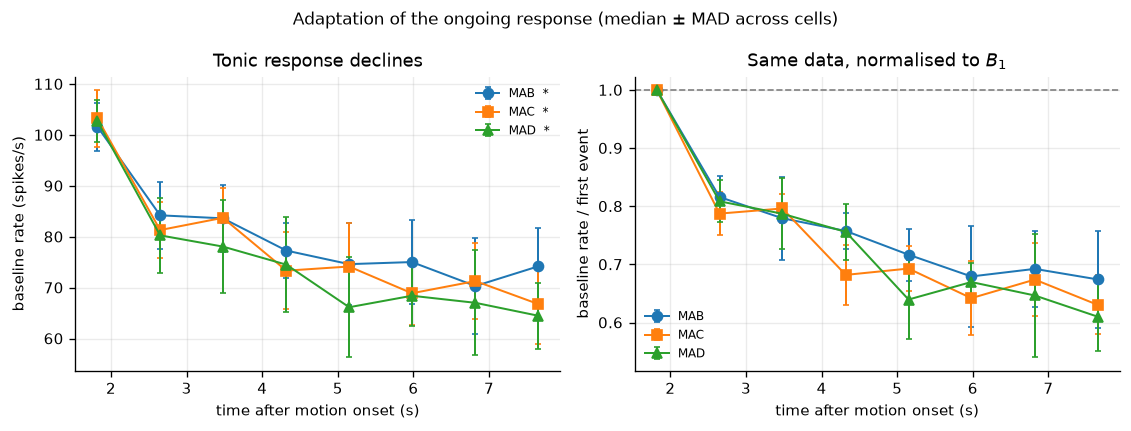

condition  Rest    B1    B8  B8/B1  Post1   S  p_mannkendall_decrease  p_wilcoxon verdict
      MAB 19.62 101.6 74.18 0.7299  13.66 -24               0.0008681    0.007812       *
      MAC 19.74 103.3 66.78 0.6467  14.09 -22                0.002753    0.007812       *
      MAD 19.78 102.7 64.48 0.6277  14.87 -24               0.0008681    0.007812       *


In [12]:
fig, (ax_rate, ax_norm) = plt.subplots(1, 2, figsize=(9.5, 3.6))
tonic_rows = []

for condition in CONDITIONS:
    subset = pooled[pooled["condition"] == condition]
    style = COND_STYLE.get(condition, {})

    median, spread, wide = population_curve(subset, "B_mean")
    S, p = mann_kendall(median, alternative="less")
    _, p_wx = late_vs_early(subset, "B_mean", alternative="less")

    ax_rate.errorbar(ONSETS / 1000, median, yerr=spread, capsize=2, lw=1.2,
                     label=f"{condition}  {stars(p)}", **style)

    relative_to_first = wide.div(wide[1], axis=0)
    ax_norm.errorbar(ONSETS / 1000, relative_to_first.median(), yerr=mad(relative_to_first.to_numpy(float), axis=0),
                     capsize=2, lw=1.2, label=condition, **style)

    # Rest and Post1 are single windows per recording, so they belong in the table
    # rather than the axes: plotting them would squash the range of interest.
    ctx = context[context["condition"] == condition]
    tonic_rows.append({
        "condition": condition,
        "Rest": np.average(ctx["Rest_mean"], weights=ctx["n"]),
        "B1": median[0],
        "B8": median[-1],
        "B8/B1": median[-1] / median[0],
        "Post1": np.average(ctx["Post1_mean"], weights=ctx["n"]),
        "S": S,
        "p_mannkendall_decrease": p,
        "p_wilcoxon": p_wx,
        "verdict": stars(p),
    })

ax_rate.set(xlabel="time after motion onset (s)", ylabel="baseline rate (spikes/s)",
            title="Tonic response declines")
ax_norm.axhline(1.0, ls="--", c="grey", lw=1)
ax_norm.set(xlabel="time after motion onset (s)", ylabel="baseline rate / first event",
            title="Same data, normalised to $B_1$")
ax_rate.legend(fontsize=7, frameon=False)
ax_norm.legend(fontsize=7, frameon=False)
fig.suptitle("Adaptation of the ongoing response (median $\\pm$ MAD across cells)", fontsize=10)
fig.tight_layout()
plt.show()

tonic_summary = pd.DataFrame(tonic_rows)
print(tonic_summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

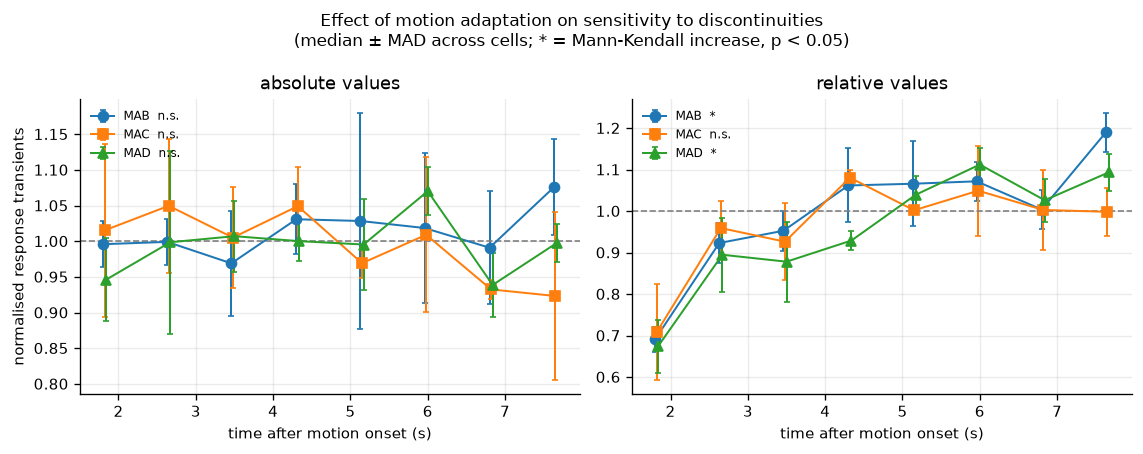

 measure condition  N   S     p_mk     p_wx
abs_norm       MAB  7   8   0.1994   0.1875
abs_norm       MAC  7 -18   0.9929   0.8906
abs_norm       MAD  7   0   0.5476   0.2891
rel_norm       MAB  7  22 0.002753 0.007812
rel_norm       MAC  7  10   0.1375  0.07812
rel_norm       MAD  7  20 0.007068  0.01562


In [15]:
def plot_transients(frame, columns=("abs_norm", "rel_norm"),
                    titles=("absolute values", "relative values"),
                    suptitle="Sensitivity to stimulus discontinuities"):
    fig, axes = plt.subplots(1, len(columns), figsize=(4.8 * len(columns), 3.8), sharex=True)
    axes = np.atleast_1d(axes)
    collected = []

    for ax, column, title in zip(axes, columns, titles):
        for offset, condition in enumerate(CONDITIONS):
            subset = frame[frame["condition"] == condition]
            res = test_condition(subset, column, alternative="greater")
            style = COND_STYLE.get(condition, {})

            # Small x-jitter so overlapping error bars stay readable.
            x = ONSETS / 1000 + (offset - (len(CONDITIONS) - 1) / 2) * 0.02
            ax.errorbar(x, res["median_curve"], yerr=res["mad_curve"], capsize=2, lw=1.2,
                        label=f"{condition}  {stars(res['p_mk'])}", **style)

            collected.append({"measure": column, "condition": condition,
                              "N": res["N_cells"], "S": res["S"],
                              "p_mk": res["p_mk"], "p_wx": res["p_wilcoxon"]})

        ax.axhline(1.0, ls="--", c="grey", lw=1)
        ax.set(xlabel="time after motion onset (s)", title=title)
        ax.legend(fontsize=7, frameon=False, loc="upper left")

    axes[0].set_ylabel("normalised response transients")
    fig.suptitle(suptitle, fontsize=10)
    fig.tight_layout()
    plt.show()
    return pd.DataFrame(collected)


main_stats = plot_transients(
    pooled,
    suptitle="Effect of motion adaptation on sensitivity to discontinuities\n"
             "(median $\\pm$ MAD across cells; * = Mann-Kendall increase, p < 0.05)",
)
print(main_stats.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

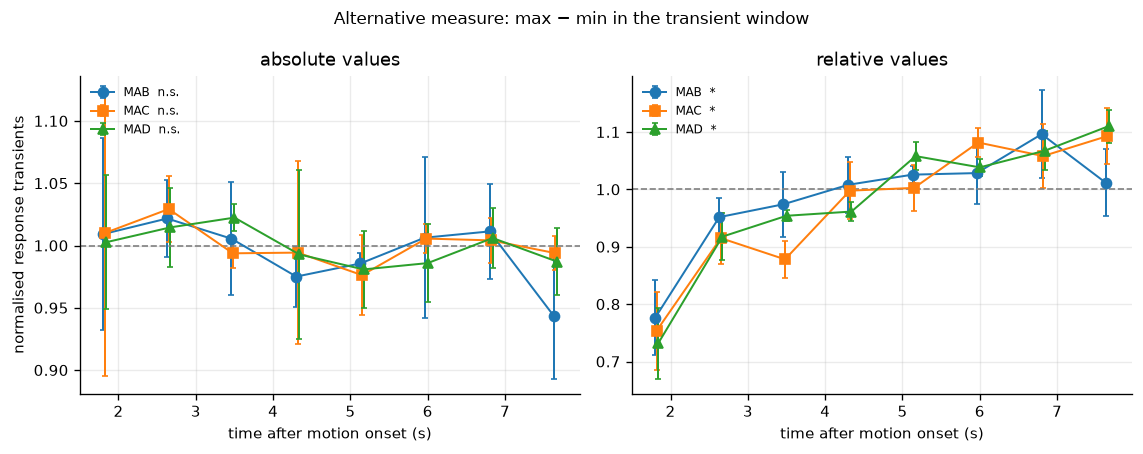

Mann-Kendall p by measure choice:
metric                 SD  max-min
measure  condition                
absolute MAB       0.1994   0.8625
         MAC       0.9929   0.8625
         MAD       0.5476   0.8625
relative MAB       0.0028   0.0028
         MAC       0.1375   0.0009
         MAD       0.0071   0.0002


In [16]:
range_stats = plot_transients(
    pooled,
    columns=("range_norm", "range_rel_norm"),
    titles=("absolute values", "relative values"),
    suptitle="Alternative measure: max $-$ min in the transient window",
)

RENAME = {"abs_norm": "absolute", "rel_norm": "relative",
          "range_norm": "absolute", "range_rel_norm": "relative"}
comparison = pd.concat([
    main_stats.assign(metric="SD"),
    range_stats.assign(metric="max-min"),
])
comparison["measure"] = comparison["measure"].map(RENAME)

print("Mann-Kendall p by measure choice:")
print(
    comparison.pivot_table(index=["measure", "condition"], columns="metric", values="p_mk")
    .to_string(float_format=lambda v: f"{v:.4f}")
)

### 8b. Blocks kept separate

Because an n-weighted mean of block SDs only approximates the SD of the fully pooled PSTH, here each block is normalised on its own and treated as an independent series. If the result survives, the pooling approximation is not driving it.

In [17]:
# Normalise within each block, using cell+block as the replication unit.
unpooled = long.copy()
unpooled["cell"] = unpooled["cell"] + "/b" + unpooled["block"].astype(str)
unpooled = normalise_by_median(unpooled, ["abs", "rel"])
unpooled["n_total"] = unpooled["n"]

unpooled_rows = []
for condition in CONDITIONS:
    subset = unpooled[unpooled["condition"] == condition]
    for column, name in [("abs_norm", "absolute"), ("rel_norm", "relative")]:
        res = test_condition(subset, column)
        unpooled_rows.append({
            "condition": condition,
            "measure": name,
            "N_series": res["N_cells"],
            "S": res["S"],
            "p_mk": res["p_mk"],
            "verdict": stars(res["p_mk"]),
        })

unpooled_stats = pd.DataFrame(unpooled_rows)

print("Blocks kept separate (each block its own series):")
print(unpooled_stats.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print()
print("Compare with blocks pooled (section 7b):")
print(
    main_stats.assign(measure=main_stats["measure"].map(RENAME))
    .loc[:, ["condition", "measure", "N", "S", "p_mk"]]
    .to_string(index=False, float_format=lambda v: f"{v:.4g}")
)

Blocks kept separate (each block its own series):
condition  measure  N_series   S     p_mk verdict
      MAB absolute        28  16  0.03051       *
      MAB relative        28  22 0.002753       *
      MAC absolute        28 -10   0.9106    n.s.
      MAC relative        28  18  0.01558       *
      MAD absolute        28   8   0.1994    n.s.
      MAD relative        28  18  0.01558       *

Compare with blocks pooled (section 7b):
condition  measure  N   S     p_mk
      MAB absolute  7   8   0.1994
      MAC absolute  7 -18   0.9929
      MAD absolute  7   0   0.5476
      MAB relative  7  22 0.002753
      MAC relative  7  10   0.1375
      MAD relative  7  20 0.007068


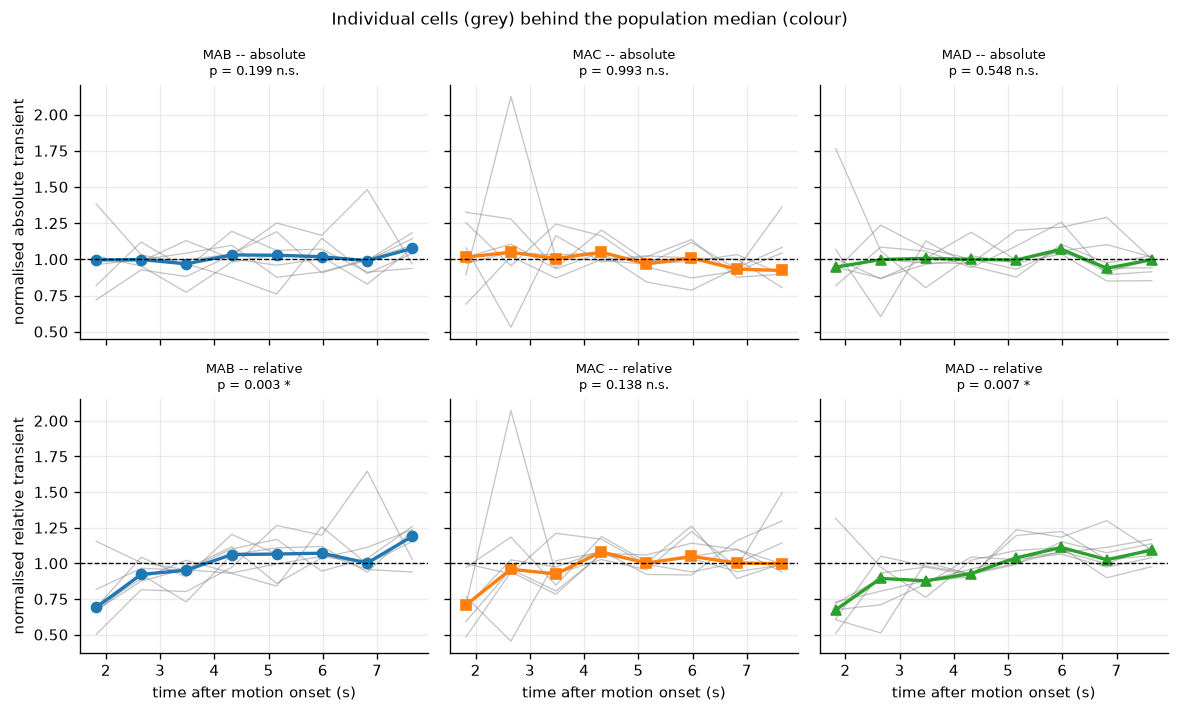

In [18]:
fig, axes = plt.subplots(2, len(CONDITIONS), figsize=(3.3 * len(CONDITIONS), 6), sharex=True, sharey="row")

for row, (column, row_label) in enumerate([("abs_norm", "absolute"), ("rel_norm", "relative")]):
    for col, condition in enumerate(CONDITIONS):
        ax = axes[row, col]
        subset = pooled[pooled["condition"] == condition]
        res = test_condition(subset, column)

        for cell, series in res["per_cell"].iterrows():
            ax.plot(ONSETS / 1000, series.to_numpy(float), color="grey", alpha=0.45, lw=0.8)

        style = COND_STYLE.get(condition, {})
        ax.plot(ONSETS / 1000, res["median_curve"], lw=2, **style)
        ax.axhline(1.0, ls="--", c="k", lw=0.8)
        ax.set_title(f"{condition} -- {row_label}\n"
                     f"p = {res['p_mk']:.3f} {stars(res['p_mk'])}", fontsize=8)
        if row == 1:
            ax.set_xlabel("time after motion onset (s)")
        if col == 0:
            ax.set_ylabel(f"normalised {row_label} transient")

fig.suptitle("Individual cells (grey) behind the population median (colour)", fontsize=10)
fig.tight_layout()
plt.show()

In [19]:
sign_rows = []
for condition in CONDITIONS:
    subset = pooled[pooled["condition"] == condition]
    peak = subset["peak"]
    sign_rows.append({
        "condition": condition,
        "median_baseline": subset["B_mean"].median(),
        "median_peak_deflection": peak.median(),
        "direction": "upward" if peak.median() > 0 else "downward",
        "frac_upward": float((peak > 0).mean()),
        "median_SD": subset["abs"].median(),
    })

sign_summary = pd.DataFrame(sign_rows)
print("Direction of the transient relative to the ongoing baseline rate:")
print(sign_summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print()
if sign_summary["frac_upward"].between(0.05, 0.95).any():
    print("Note: at least one condition is mixed, so its transients are not consistently")
    print("one-directional across cells and events. Interpret its sign with care.")
else:
    print("Each condition has a consistent direction across cells and events.")

Direction of the transient relative to the ongoing baseline rate:
condition  median_baseline  median_peak_deflection direction  frac_upward  median_SD
      MAB            77.56                   81.75    upward            1      8.461
      MAC            74.55                   140.7    upward            1      8.872
      MAD            72.34                   214.6    upward            1      8.892

Each condition has a consistent direction across cells and events.


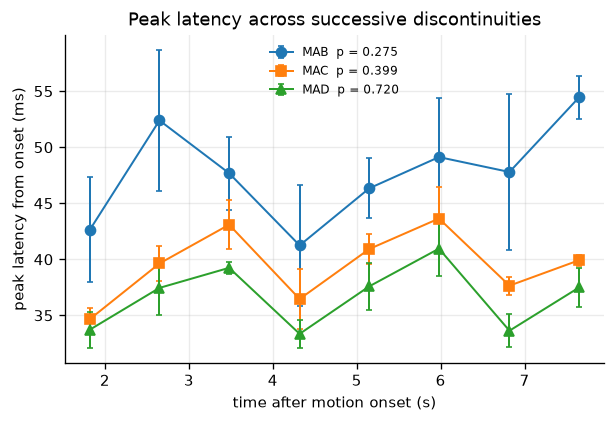

condition  first_ms  last_ms  S  p_two_sided verdict
      MAB     42.64    54.47 10       0.2751    n.s.
      MAC     34.67    39.93  8       0.3988    n.s.
      MAD     33.73     37.5  4       0.7195    n.s.

Transient window is 150 ms wide, so latencies are bounded by it.


In [20]:
# Latency of the extreme that defines the peak, measured from discontinuity onset.
lat = long.copy()
_use_max = (lat["T_max_val"] - lat["B_mean"]).abs() >= (lat["T_min_val"] - lat["B_mean"]).abs()
lat["peak_latency"] = np.where(_use_max, lat["T_max_t"], lat["T_min_t"]) - lat["onset_ms"]

lat_pooled = pool_blocks(lat, value_cols=["peak_latency"])
lat_pooled["onset_ms"] = ONSETS[lat_pooled["event"].to_numpy() - 1]

fig, ax = plt.subplots(figsize=(5.2, 3.6))
lat_rows = []
for condition in CONDITIONS:
    subset = lat_pooled[lat_pooled["condition"] == condition]
    median, spread, _ = population_curve(subset, "peak_latency")
    S, p = mann_kendall(median, alternative="two-sided")
    ax.errorbar(ONSETS / 1000, median, yerr=spread, capsize=2, lw=1.2,
                label=f"{condition}  p = {p:.3f}",
                **COND_STYLE.get(condition, {}))
    lat_rows.append({"condition": condition, "first_ms": median[0], "last_ms": median[-1],
                     "S": S, "p_two_sided": p, "verdict": stars(p)})

ax.set(xlabel="time after motion onset (s)", ylabel="peak latency from onset (ms)",
       title="Peak latency across successive discontinuities")
ax.legend(fontsize=7, frameon=False)
fig.tight_layout()
plt.show()

latency_summary = pd.DataFrame(lat_rows)
print(latency_summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))
print()
print(f"Transient window is {windows.loc['T1', 'dur_ms']} ms wide, so latencies are bounded by it.")

In [21]:
transient_summary = results_table(pooled, ["abs_norm", "rel_norm", "range_norm", "range_rel_norm"])
transient_summary.insert(3, "direction_tested", "increase")

tonic_block = tonic_summary.rename(columns={
    "B1": "first_event", "B8": "last_event", "p_mannkendall_decrease": "p_mannkendall"
}).assign(measure="B_mean (tonic rate)", direction_tested="decrease", N_cells=len(CELLS))
tonic_block["n_trials_total"] = [
    int(pooled.loc[pooled["condition"] == c].groupby("cell")["n_total"].first().sum())
    for c in tonic_summary["condition"]
]

summary = pd.concat([tonic_block, transient_summary], ignore_index=True)[[
    "condition", "measure", "direction_tested", "N_cells", "n_trials_total",
    "first_event", "last_event", "S", "p_mannkendall", "p_wilcoxon", "verdict",
]]

summary.to_csv(SUMMARY_CSV, index=False)
print(f"written to {SUMMARY_CSV.relative_to(REPO)}")
print()
print(summary.to_string(index=False, float_format=lambda v: f"{v:.4g}"))

written to summary.csv

condition             measure direction_tested  N_cells  n_trials_total  first_event  last_event   S  p_mannkendall  p_wilcoxon verdict
      MAB B_mean (tonic rate)         decrease        7             282        101.6       74.18 -24      0.0008681    0.007812       *
      MAC B_mean (tonic rate)         decrease        7             284        103.3       66.78 -22       0.002753    0.007812       *
      MAD B_mean (tonic rate)         decrease        7             283        102.7       64.48 -24      0.0008681    0.007812       *
      MAB            abs_norm         increase        7             282       0.9958       1.075   8         0.1994      0.1875    n.s.
      MAB            rel_norm         increase        7             282        0.691       1.189  22       0.002753    0.007812       *
      MAB          range_norm         increase        7             282        1.009      0.9436  -8         0.8625      0.8906    n.s.
      MAB      range_rel

In [22]:
# Surface the recording notes so the sweeps that cannot be excluded stay documented.
for note in sorted(NOTES_DIR.glob("Readme_Zelle*.md")):
    body = "\n".join(
        line for line in note.read_text().splitlines() if line.strip() and line.strip() != "#"
    )
    print(f"----- {note.name} -----")
    print(body)
    print()

----- Readme_Zelle01.md -----
# Readme zu Zelle 01
# Auswertung
** Schwelle angepasst **
# Sweep 19, 28, 72, 94, 96, 98, 106, 108, 109, 115, 117, 118
** Auto detect > 0  
# 1 Linienbreite
# 72, 73,  94, 108
# >=2 Linienbreiten (wird invalid)
# 96, 109

----- Readme_Zelle02.md -----
# Readme zu Zelle 02
# Auswertung
** Schwelle angepasst **
# 78, 94, 95, 99
** Auto detect > 0  
# 1 Linienbreite
# >=2 Linienbreiten (wird invalid)

----- Readme_Zelle03.md -----
# Readme zu Zelle 03
# Auswertung
** Schwelle angepasst **
# 11, 61, 79, 128
** Auto detect > 0  
# 1 Linienbreite
# 11
# >=2 Linienbreiten (wird invalid)

----- Readme_Zelle04.md -----
# Readme zu Zelle 04
1-8 Quality
# Auswertung
** Schwelle angepasst **
# 2, 12, 25, 26, 29, 48, 58, 62, 63, 66, 72, 84, 87, 90, 91, 95, 100, 103, 105, 106, 111, 113
** Auto detect > 0  
# 1 Linienbreite
# 25, 26, 28, 47, 48, 63, 66, 87, 103, 106, 113
# >=2 Linienbreiten (wird invalid)
# 1, 2, 7, 46, 56, 57, 58, 60, 62

----- Readme_Zelle05.md -----
